## BUSINESS UNDERSTANDING

The 2024 Indonesian presidential election has generated immense public discourse on social media, making these platforms a rich source of public opinion. The core problem this project addresses is the classification of public sentiment from social media text, specifically focusing on translated tweets related to Prabowo Subianto and other presidential candidates. By accurately identifying sentiment, we can gauge public reactions, track evolving opinions, and provide a clear picture of the political landscape.

From a machine learning perspective, this is framed as a binary text classification problem using supervised learning. The primary objective is to compare the performance of three specific recurrent neural network (RNN) architectures: LSTM, BiLSTM, and GRU. The business value of this project lies in providing political analysts, campaign managers, and the public with data-driven insights into opinion trends, ultimately demonstrating how deep learning can distill massive amounts of unstructured text into actionable intelligence.

In [1]:
# import subprocess
# import sys

# print("Memulai instalasi library ke environment Jupyter...")
# # Menginstal semua paket langsung menggunakan Python kernel yang sedang aktif
# try:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "tensorflow"])
#     print("✅ Instalasi Berhasil!")
# except Exception as e:
#     print("❌ Instalasi Gagal:", e)


=== DATA UNDERSTANDING ===
File original ditemukan: 3 file.
File labeled ditemukan : 3 file.



Total Keseluruhan Baris: 30000
Total Kolom: 4
Kolom Teks Mentah yang digunakan untuk preprocessing: 'raw_text'
Kolom Label yang digunakan: 'label'

Distribusi Label Sentimen:
label
Positive    21654
Negative     8343
Name: count, dtype: int64


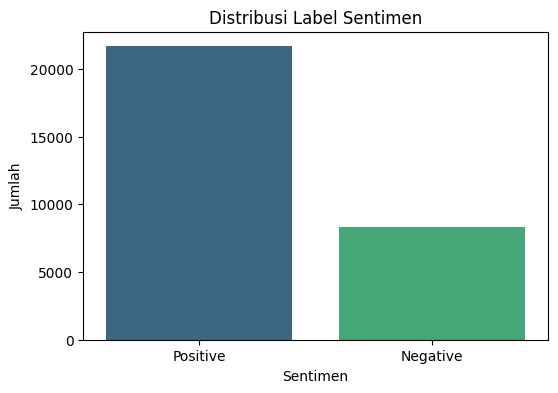


Contoh Data Mentah/Kotor Sebelum Preprocessing:


,candidate,raw_text,label
0,Anies Baswedan,info anies presiden,Positive
1,Anies Baswedan,politisi partai gerindra sandiaga uno menjawab...,Positive
2,Anies Baswedan,lanjut pak anies kita kawal sampai jadi presiden,Positive
3,Anies Baswedan,semoga allah swt menyelamatkan bangsa dan nega...,Positive
4,Anies Baswedan,chotimah kasian ya pa anies makanya sudah teka...,Positive



Contoh Kolom Teks Terjemahan dari Dataset Labeled:


,candidate,Text,label
0,Anies Baswedan,anies president info,Positive
1,Anies Baswedan,gerindra party politician sandiaga uno answers...,Positive
2,Anies Baswedan,"mr. anies continued, we will guard him until h...",Positive
3,Anies Baswedan,may allah swt save the nation and state of the...,Positive
4,Anies Baswedan,"poor chotimah, uncle anies, that's why my fami...",Positive


In [2]:
# ==========================================
# CELL 1: DATA UNDERSTANDING & LOAD DATA MENTAH
# ==========================================
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

print("=== DATA UNDERSTANDING ===")

# Dataset original berisi teks mentah/kotor pada kolom 'Tweet'.
# Dataset labeled berisi hasil terjemahan pada kolom 'Text' dan label sentimen.
# Keduanya digabung per kandidat berdasarkan urutan baris agar preprocessing bisa didemokan dari data kotor,
# sementara modeling tetap memiliki label Positive/Negative.
original_paths = sorted(glob.glob("data/original data/*.csv"))
labeled_paths = sorted(glob.glob("data/labeled data/*.csv"))

print(f"File original ditemukan: {len(original_paths)} file.")
print(f"File labeled ditemukan : {len(labeled_paths)} file.")

def read_csv_with_fallback(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='latin1')

if len(original_paths) > 0 and len(labeled_paths) > 0:
    df_list = []

    for original_path, labeled_path in zip(original_paths, labeled_paths):
        candidate_name = os.path.splitext(os.path.basename(original_path))[0]
        df_original = read_csv_with_fallback(original_path)
        df_labeled = read_csv_with_fallback(labeled_path)

        # Mengambil panjang minimum untuk berjaga-jaga jika ada selisih jumlah baris.
        n_rows = min(len(df_original), len(df_labeled))

        df_candidate = pd.DataFrame({
            'candidate': candidate_name,
            'raw_text': df_original.loc[:n_rows - 1, 'Tweet'].reset_index(drop=True),
            'Text': df_labeled.loc[:n_rows - 1, 'Text'].reset_index(drop=True),
            'label': df_labeled.loc[:n_rows - 1, 'label'].reset_index(drop=True)
        })
        df_list.append(df_candidate)

    df = pd.concat(df_list, ignore_index=True)

    # Kolom raw_text dipakai untuk demo preprocessing; kolom label dipakai sebagai target klasifikasi.
    text_col = 'raw_text'
    label_col = 'label'

    print(f"\nTotal Keseluruhan Baris: {df.shape[0]}")
    print(f"Total Kolom: {df.shape[1]}")
    print(f"Kolom Teks Mentah yang digunakan untuk preprocessing: '{text_col}'")
    print(f"Kolom Label yang digunakan: '{label_col}'")

    print("\nDistribusi Label Sentimen:")
    distribusi = df[label_col].value_counts()
    print(distribusi)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=label_col, hue=label_col, palette='viridis', legend=False)
    plt.title('Distribusi Label Sentimen')
    plt.xlabel('Sentimen')
    plt.ylabel('Jumlah')
    plt.show()

    print("\nContoh Data Mentah/Kotor Sebelum Preprocessing:")
    display(df[['candidate', text_col, label_col]].head())

    print("\nContoh Kolom Teks Terjemahan dari Dataset Labeled:")
    display(df[['candidate', 'Text', label_col]].head())
else:
    print("File CSV tidak ditemukan. Pastikan direktori 'data/original data/' dan 'data/labeled data/' sudah benar.")


In [ ]:
# ==========================================
# CELL 2: PREPROCESSING TEKS & LABEL
# ==========================================
import re

print("=== PREPROCESSING TEKS & LABEL ===")

def remove_url_and_non_alpha(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text

def case_folding(text):
    return str(text).lower()

def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

def clean_text(text):
    text = remove_url_and_non_alpha(text)
    text = case_folding(text)
    text = remove_extra_spaces(text)
    return text

def show_before_after(title, examples, transform_func, before_label='Sebelum', after_label='Sesudah'):
    demo_df = pd.DataFrame({before_label: examples})
    demo_df[after_label] = demo_df[before_label].apply(transform_func)
    print(f"\n{title}")
    display(demo_df)

# Contoh dibuat eksplisit agar perubahan tiap tahap terlihat jelas saat demo presentasi.
# Dataset original yang digunakan sudah relatif bersih, lowercase, dan hampir tidak memiliki URL/simbol.
show_before_after(
    'Penghapusan URL dan Karakter Spesial (Non-Alfabet)',
    [
        'gerindra party politician https://t.co/xyz answers...',
        'may allah swt save the nation & state of the republic #2024'
    ],
    lambda text: remove_extra_spaces(remove_url_and_non_alpha(text)),
    before_label='Sebelum Penghapusan Karakter Non-Alfabet & URL',
    after_label='Sesudah Penghapusan Karakter Non-Alfabet & URL'
)

show_before_after(
    'Case Folding (Lowercase)',
    [
        'Mr Anies Continued We Will Guard Him',
        'Anies President Info'
    ],
    case_folding,
    before_label='Sebelum Case Folding',
    after_label='Sesudah Case Folding'
)

show_before_after(
    'Penghapusan Spasi Berlebihan',
    [
        'may allah swt save the nation   state of the republic',
        'poor chotimah  uncle anies  that s why my family   '
    ],
    remove_extra_spaces,
    before_label='Sebelum',
    after_label='Sesudah'
)

# Penerapan preprocessing ke dataset original/kotor.
df['text_no_special'] = df[text_col].apply(remove_url_and_non_alpha)
df['text_lower'] = df['text_no_special'].apply(case_folding)
df['cleaned_text'] = df['text_lower'].apply(remove_extra_spaces)

# Filtering data dan konversi label target.
df_clean = df.copy()
df_clean = df_clean.dropna(subset=[label_col, 'cleaned_text'])
df_clean = df_clean[df_clean[label_col].astype(str).str.lower().isin(['positive', 'negative'])]
df_clean = df_clean[df_clean['cleaned_text'].str.len() > 0]

# Untuk demo preprocessing, kolom cleaned_text berasal dari raw_text original/kotor.
# Untuk modeling, digunakan kolom Text dari dataset labeled/bersih agar performa setara eksperimen utama.
df_clean['modeling_text'] = df_clean['Text'].apply(clean_text)
df_clean = df_clean[df_clean['modeling_text'].str.len() > 0]

label_mapping = {'positive': 1, 'negative': 0}
df_clean['target'] = df_clean[label_col].astype(str).str.lower().map(label_mapping)

print("\nFiltering Data dan Konversi Label")
print(f"Jumlah baris sebelum filtering: {len(df)}")
print(f"Jumlah baris setelah dibersihkan dan difilter: {len(df_clean)}")

print("\nHasil Akhir Preprocessing dari Data Original/Kotor")
display(df_clean[['candidate', text_col, 'cleaned_text', label_col, 'target']].head())

print("\nTeks yang Digunakan untuk Modeling")
display(df_clean[['modeling_text', label_col, 'target']].head())


In [ ]:
# ==========================================
# CELL 3: SPLIT DATA
# ==========================================
from sklearn.model_selection import train_test_split

print("=== SPLIT DATA (TRAIN, VAL, TEST) ===")

# Pertama, pisahkan 80% untuk (Train+Val) dan 20% untuk Test
# Modeling memakai modeling_text dari dataset labeled/bersih.
# cleaned_text tetap dipakai untuk menampilkan demo preprocessing data kotor.
X_temp, X_test, y_temp, y_test = train_test_split(
    df_clean['modeling_text'], 
    df_clean['target'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_clean['target']
)

# Kedua, pisahkan sisa 80% tadi menjadi 60% Train dan 20% Validation
# (0.25 dari 80% adalah 20% dari total dataset)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)

print(f"Data Train: {len(X_train)} baris")
print(f"Data Validation: {len(X_val)} baris")
print(f"Data Test: {len(X_test)} baris")


In [ ]:
# ==========================================
# CELL 4: TOKENIZATION & PADDING
# ==========================================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("=== TOKENIZATION & PADDING ===")

# Parameter
vocab_size = 5000       # Maksimal kata unik yang disimpan
max_length = 100        # Panjang maksimal sequence kalimat
oov_tok = "<OOV>"       # Token untuk kata yang tidak ada di vocabulary

# 1. Inisiasi dan Fit Tokenizer pada data Train
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# 2. Mengubah teks menjadi sequences (urutan angka)
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)

# 3. Menyamakan panjang (Padding)
X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(val_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Proses Tokenisasi dan Padding Selesai.")
print(f"Bentuk X_train_pad: {X_train_pad.shape}")
print(f"Bentuk X_val_pad  : {X_val_pad.shape}")
print(f"Bentuk X_test_pad : {X_test_pad.shape}")


In [ ]:
# ==========================================
# CELL 5: SETUP MODEL & CALLBACKS
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

print("=== PERSIAPAN MODELING ===")

# Parameter arsitektur Neural Network
embedding_dim = 128
epochs = 5
batch_size = 64

# Callback: Hentikan training jika val_loss tidak membaik dalam 2 epoch
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Tempat menyimpan history training untuk visualisasi nanti
training_histories = {}


In [ ]:
# ==========================================
# CELL 6: MODEL LSTM
# ==========================================
print("=== MELATIH MODEL LSTM ===")
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # sigmoid untuk binary classification (0 atau 1)
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

start_time = time.time()
training_histories['LSTM'] = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan LSTM: {time.time() - start_time:.2f} detik")


In [ ]:
# ==========================================
# CELL 7: MODEL BiLSTM
# ==========================================
print("\n=== MELATIH MODEL BiLSTM ===")
model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

start_time = time.time()
training_histories['BiLSTM'] = model_bilstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan BiLSTM: {time.time() - start_time:.2f} detik")


In [ ]:
# ==========================================
# CELL 8: MODEL GRU
# ==========================================
print("\n=== MELATIH MODEL GRU ===")
model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    GRU(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gru.summary()

start_time = time.time()
training_histories['GRU'] = model_gru.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan GRU: {time.time() - start_time:.2f} detik")


In [ ]:
# ==========================================
# CELL 9: EVALUASI MODEL
# ==========================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("=== EVALUASI PADA DATA TEST ===")

models = {
    'LSTM': model_lstm,
    'BiLSTM': model_bilstm,
    'GRU': model_gru
}

predictions = {}

for name, model in models.items():
    print(f"\n--- Evaluasi Model {name} ---")
    
    # Memprediksi probabilitas
    y_pred_probs = model.predict(X_test_pad)
    # Mengubah probabilitas menjadi kelas 0 atau 1
    y_pred = (y_pred_probs > 0.5).astype(int)
    predictions[name] = y_pred
    
    # Menghitung Metrik
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Menampilkan Classification Report lengkap (Precision, Recall, F1-Score)
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


In [ ]:
# ==========================================
# CELL 10: VISUALISASI HASIL PELATIHAN
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("=== VISUALISASI TRAINING & CONFUSION MATRIX ===")

# 1. Grafik Accuracy dan Loss dari Proses Training
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy Plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    ax1.set_title(f'{model_name} - Accuracy Curve')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss Plot
    ax2.plot(history.history['loss'], label='Train Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    ax2.set_title(f'{model_name} - Loss Curve')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Menampilkan grafik untuk tiap model
for name, history in training_histories.items():
    plot_history(history, name)

# 2. Confusion Matrix Heatmap (Mengambil model BiLSTM sebagai contoh terbaik)
best_model_name = 'BiLSTM'
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
